## Partie PINN — Physics-Informed Neural Network

Contrairement au MLP (purement supervisé), le PINN apprend en minimisant
un résidu de l'EDP elle-même, en plus de quelques données (condition
initiale + conditions aux limites). Le résidu est calculé par
différentiation automatique (`torch.autograd`) :

R(x, t) = ∂u/∂t − D ∂²u/∂x² + αu

La fonction de coût combine deux termes (cf. section 8 du sujet) :

L = L_data + λ · L_PDE,   où L_PDE = (1/N) Σᵢ R(xᵢ, tᵢ)²

Contrairement au MLP, le PINN reçoit D et alpha comme paramètres du calcul
du résidu (pas comme entrées du réseau) : on peut donc le ré-entraîner
pour n'importe quel scénario physique, ce que le MLP ne pouvait pas faire.
#### Résidu
 Résidu de l'EDP : R = u_t - D*u_xx + alpha*u 
 On calcule les dérivées de u par rapport à x et t par différentiation
automatique (et non par différences finies) :
  1) requires_grad_(True) sur x et t : on demande à PyTorch de garder
     la trace des opérations pour pouvoir dériver par rapport à elles ;
  2) u_t, u_x : dérivées premières (torch.autograd.grad) ;
  3) u_xx : dérivée seconde, obtenue en dérivant u_x par rapport à x
     une seconde fois (create_graph=True est nécessaire à chaque étape
     pour pouvoir dériver encore après) ;
  4) le résidu doit théoriquement être nul partout si u vérifie l'EDP :
      c'est ce résidu (au carré) que le PINN va chercher à minimiser.

In [91]:
# fonction.py est resté à la racine du projet (partagé par tous les
# notebooks) : chaque notebook vivant maintenant dans son propre
# dossier, on ajoute le dossier parent au chemin d'import.
import sys, os
sys.path.append(os.path.abspath('..'))

from fonction import *

In [92]:
# Condition initiale : u(x, 0) = A exp(-(x-x0)²/sigma²), échantillonnée
# en N_ic points aléatoires sur [-L, L]
N_ic = 300
x_ic = np.random.uniform(-L, L, N_ic)
t_ic = np.zeros(N_ic)
u_ic = u_analytique(x_ic, t_ic, A, x0, sigma, D, alpha)

x_ic = torch.tensor(x_ic, dtype=torch.float32).view(-1,1)
t_ic = torch.tensor(t_ic, dtype=torch.float32).view(-1,1)
u_ic = torch.tensor(u_ic, dtype=torch.float32).view(-1,1)
# Conditions aux limites : Dirichlet non-homogènes, imposées sur toute la
# durée T aux MÊMES points que les Volumes Finis, c'est-à-dire aux centres
# des cellules de bord x = ±(L - dx/2) (et non exactement x = ±L, cf. xb
# ci-dessous). On impose la solution analytique en ces points.
N_bc = 300
dx_bc = 2 * L / Nx
xb = L - dx_bc / 2          # = 9.95 avec Nx=200, L=10 — même point que les VF
t_bc = np.random.uniform(0, T, N_bc)
x_bc = np.where(np.arange(N_bc) < N_bc // 2, -xb, xb).astype(float)
u_bc = u_analytique(x_bc, t_bc, A, x0, sigma, D, alpha)

x_bc = torch.tensor(x_bc, dtype=torch.float32).view(-1,1)
t_bc = torch.tensor(t_bc, dtype=torch.float32).view(-1,1)
u_bc = torch.tensor(u_bc, dtype=torch.float32).view(-1,1)


In [93]:
# --- Concaténation des points IC et BC en un seul jeu "données" ---
x_data = torch.cat([x_ic, x_bc])
t_data = torch.cat([t_ic, t_bc])
u_data = torch.cat([u_ic, u_bc])

In [94]:

# --- Grille de référence pour toutes les évaluations du PINN dans ce fichier ---
# On charge aussi le MLP déjà entraîné (cf. MLP.ipynb), nécessaire pour la
# comparaison finale à 4 courbes (Analytique / VF / MLP / PINN) plus bas.
x_grille, t_grille, U_vf_grille = u_volume_finie()
X_mesh, T_mesh = np.meshgrid(x_grille, t_grille)
model_mlp, stats = charger_mlp('../mlp_reference.pth')
U_mlp_grille = predire_mlp(model_mlp, stats, X_mesh, T_mesh)

In [95]:
epochs = 2000
lr = 1e-3
lambda_pde = 8.0
print_every = 200

### Boucle d'entraînement (phase 1 : Adam) 
 À CHAQUE epoch, on tire N_r = 600 nouveaux points de collocation:contrairement aux points
 IC/BC (fixes), les points physiques changent à chaque itération.
 Cela évite que le PINN "apprenne par cœur" un jeu fixe de points et
 l'oblige à satisfaire l'EDP partout dans le domaine, pas seulement
 en quelques endroits.

In [96]:
def train(model, X_data, y_data, epochs=epochs, lr=lr, lambda_pde=lambda_pde,
          patience=200, check_every=10, N_val=2000):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    torch.manual_seed(0)
    np.random.seed(0)

    # Points de validation FIXES : critère d'arrêt non bruité
    x_v = torch.tensor(np.random.uniform(-L, L, N_val), dtype=torch.float32).view(-1,1)
    t_v = torch.tensor(np.random.uniform(0, T, N_val), dtype=torch.float32).view(-1,1)
    X_val = torch.cat([x_v, t_v], dim=1)
    best_val, best_epoch, best_state = float('inf'), 0, None

    for epoch in range(epochs+1):
        model.train()
        optimizer.zero_grad()

        N_r = 600
        x_r = torch.tensor(np.random.uniform(-L, L, N_r), dtype=torch.float32).view(-1,1)
        t_r = torch.tensor(np.random.uniform(0, T, N_r), dtype=torch.float32).view(-1,1)
        X_phys = torch.cat([x_r, t_r], dim=1)

        loss_total, loss_data, loss_phys = pinn_loss(model, X_data, y_data, X_phys, lambda_pde, alpha, D)
        loss_total.backward()
        optimizer.step()
        hist['total_loss'].append(loss_total.item())
        hist['data_loss'].append(loss_data.item())
        hist['phys_loss'].append(loss_phys.item())

        # --- Arrêt anticipé sur la loss de validation ---
        if epoch % check_every == 0:
            val = pinn_loss(model, X_data, y_data, X_val, lambda_pde, alpha, D)[0].item()
            if val < best_val * (1 - 1e-3):          # amélioration relative > 0.1 %
                best_val, best_epoch = val, epoch
                best_state = snapshot_state_dict(model)  # copie réelle et indépendante
            if epoch - best_epoch >= patience:
                print(f"Arrêt anticipé à l'epoch {epoch} (meilleure : {best_epoch}, val = {best_val:.3e})")
                break

        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | Data: {loss_data.item():.6f} | Phys: {loss_phys.item():.6f} | Total: {loss_total.item():.6f}")
    else:   
        print(f"Pas d'arrêt anticipé : {epochs} epochs (meilleure : {best_epoch}, val = {best_val:.3e})")

    assert best_state is not None, (
        "Aucun meilleur état mémorisé pendant l'entraînement du PINN.")
    model.load_state_dict(best_state)   # on restaure les meilleurs poids
    return model

In [97]:
hist = {'total_loss': [], 'data_loss': [], 'phys_loss': []}
X_data = torch.cat([x_data, t_data], dim=1)
torch.manual_seed(0)                     # avant la création du modèle (voir ci-dessous)
pinn = PINN(hidden_dim=32)

t0 = time.perf_counter()
pinn = train(pinn, X_data, u_data)       # UN SEUL appel
t_adam = time.perf_counter() - t0
print(f"Temps Adam : {t_adam:.1f} s")

Epoch    0 | Data: 0.431365 | Phys: 0.004761 | Total: 0.469456
Epoch  200 | Data: 0.002568 | Phys: 0.000020 | Total: 0.002726
Epoch  400 | Data: 0.001976 | Phys: 0.000006 | Total: 0.002023
Epoch  600 | Data: 0.001876 | Phys: 0.000003 | Total: 0.001896
Epoch  800 | Data: 0.001833 | Phys: 0.000002 | Total: 0.001848
Epoch 1000 | Data: 0.001788 | Phys: 0.000002 | Total: 0.001803
Epoch 1200 | Data: 0.001618 | Phys: 0.000004 | Total: 0.001653
Epoch 1400 | Data: 0.000464 | Phys: 0.000039 | Total: 0.000773
Epoch 1600 | Data: 0.000259 | Phys: 0.000022 | Total: 0.000437
Epoch 1800 | Data: 0.000194 | Phys: 0.000015 | Total: 0.000315
Epoch 2000 | Data: 0.000153 | Phys: 0.000011 | Total: 0.000239
Pas d'arrêt anticipé : 2000 epochs (meilleure : 2000, val = 2.277e-04)
Temps Adam : 11.3 s


In [98]:
# --- Évaluation AVANT L-BFGS (juste après Adam) ---
def evaluer_pinn_sur_grille(model, X_mesh, T_mesh, x_grille, t_grille, A, x0, sigma, D, alpha):
    model.eval()
    with torch.no_grad():
        xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]), dtype=torch.float32)
        U_pred = model(xt_grille).numpy().reshape(X_mesh.shape)
    U_exact = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
    diff = U_pred - U_exact
    mse = np.mean(diff**2)
    l2 = np.sqrt(mse)
    linf = np.max(np.abs(diff))
    return U_pred, mse, l2, linf

U_pinn_grille_avant, MSE_avant, L2_avant, Linf_avant = evaluer_pinn_sur_grille(
    pinn, X_mesh, T_mesh, x_grille, t_grille, A, x0, sigma, D, alpha)

print(f"AVANT L-BFGS | MSE = {MSE_avant:.3e} | L2 = {L2_avant:.3e} | L∞ = {Linf_avant:.3e}")

AVANT L-BFGS | MSE = 4.762e-05 | L2 = 6.901e-03 | L∞ = 4.337e-02


### fine-tuning avec L-BFGS(phase2) 
 Adam converge vite au début mais stagne près du minimum (bruit dû au
 tirage aléatoire des points physiques à chaque epoch). L-BFGS est un
 optimiseur de second ordre : plus lent par itération, mais capable
 d'affiner beaucoup plus finement une fois qu'on est proche d'un minimum
  d'où l'usage classique Adam (exploration) -> L-BFGS (raffinement)
 pour les PINNs (cf. Raissi et al., 2019, bibliographie du sujet).

 Contrairement à Adam, L-BFGS a besoin d'un gradient stable d'une
 itération à l'autre : on fixe donc les points de collocation une
 fois pour toute la phase (pas de rééchantillonnage à chaque itération),
 et on passe par une closure() car L-BFGS peut évaluer la fonction
 plusieurs fois par step (recherche linéaire "strong_wolfe").

In [99]:
# --- Phase 2 : fine-tuning L-BFGS après Adam ---
# # On repart du modèle pinn déjà entraîné avec Adam (cellule précédente).
# L-BFGS a besoin d'un gradient stable => on fixe les points de collocation
# une fois pour toute la phase (pas de rééchantillonnage à chaque itération).

N_r_lbfgs = 1000
x_r_lbfgs = torch.tensor(np.random.uniform(-L, L, N_r_lbfgs), dtype=torch.float32).view(-1, 1)
t_r_lbfgs = torch.tensor(np.random.uniform(0, T, N_r_lbfgs), dtype=torch.float32).view(-1, 1)
X_phys_lbfgs = torch.cat([x_r_lbfgs, t_r_lbfgs], dim=1)

optimizer_lbfgs = torch.optim.LBFGS(
    pinn.parameters(),
    lr=1.0,
    max_iter=200,
    max_eval=None,
    history_size=50,
    line_search_fn='strong_wolfe'
)

lbfgs_iter = [0]  # compteur mutable pour logger dans la closure

def closure():
    optimizer_lbfgs.zero_grad()
    loss_total, loss_data, loss_phys = pinn_loss(pinn, X_data, u_data, X_phys_lbfgs, lambda_pde, alpha, D)
    loss_total.backward()

    hist['total_loss'].append(loss_total.item())
    hist['data_loss'].append(loss_data.item())
    hist['phys_loss'].append(loss_phys.item())

    if lbfgs_iter[0] % 50 == 0:
        print(f"[L-BFGS] iter {lbfgs_iter[0]:4d} | Data: {loss_data.item():.3e} | "
              f"Phys: {loss_phys.item():.3e} | Total: {loss_total.item():.3e}")
    lbfgs_iter[0] += 1

    return loss_total

t0 = time.perf_counter()
optimizer_lbfgs.step(closure)
t_lbfgs = time.perf_counter() - t0
print(f"Temps L-BFGS : {t_lbfgs:.1f} s")
print(f"\nLoss finale après L-BFGS : {hist['total_loss'][-1]:.3e}")

[L-BFGS] iter    0 | Data: 1.530e-04 | Phys: 9.692e-06 | Total: 2.305e-04
[L-BFGS] iter   50 | Data: 2.575e-06 | Phys: 9.337e-07 | Total: 1.004e-05
[L-BFGS] iter  100 | Data: 5.456e-07 | Phys: 2.545e-07 | Total: 2.581e-06
[L-BFGS] iter  150 | Data: 1.622e-07 | Phys: 1.077e-07 | Total: 1.024e-06
[L-BFGS] iter  200 | Data: 1.254e-07 | Phys: 6.077e-08 | Total: 6.115e-07
Temps L-BFGS : 1.5 s

Loss finale après L-BFGS : 5.524e-07


In [100]:
# --- Sauvegarde du PINN entraîné (Adam + L-BFGS) ---
# Cette cellule est volontairement placée ICI, juste après la phase
# L-BFGS (cellule précédente) et AVANT la cellule d'évaluation
# "avant/après" : cela garantit sans ambiguïté que les poids sauvegardés
# sont ceux du PINN totalement affiné (Adam + L-BFGS), et pas seulement
# ceux obtenus après la phase Adam.
assert len(optimizer_lbfgs.state) > 0, "L-BFGS n'a pas encore été exécuté !"
opt_state = list(optimizer_lbfgs.state.values())[0]

torch.save({
    'model_state_dict': pinn.state_dict(),
    'hidden_dim': 32,
    'D': D, 'alpha': alpha,
    'lbfgs_n_iter': int(opt_state['n_iter']),          # vraies itérations
    'lbfgs_func_evals': int(opt_state['func_evals']),  # évaluations de la loss
    't_adam': float(t_adam),      # <-- ajouté : temps phase Adam (cellule 11)
    't_lbfgs': float(t_lbfgs),    # <-- ajouté : temps phase L-BFGS (cette cellule)
}, '../pinn_reference.pth')

print(f"PINN sauvegardé (L-BFGS : {opt_state['n_iter']} itérations, "
      f"{opt_state['func_evals']} évaluations)")

PINN sauvegardé (L-BFGS : 200 itérations, 206 évaluations)


In [101]:
# --- Évaluation APRÈS L-BFGS : comparaison avant/après affinage ---------
# Le tableau ci-dessous doit normalement montrer un gain net sur les
# trois métriques (MSE, L2, L∞) grâce au fine-tuning L-BFGS.
U_pinn_grille_apres, MSE_apres, L2_apres, Linf_apres = evaluer_pinn_sur_grille(
    pinn, X_mesh, T_mesh, x_grille, t_grille, A, x0, sigma, D, alpha)

print(f"APRÈS L-BFGS | MSE = {MSE_apres:.3e} | L2 = {L2_apres:.3e} | L∞ = {Linf_apres:.3e}")

print("\n--- Comparaison ---")
print(f"{'Métrique':10s} {'Avant':>12s} {'Après':>12s} {'Gain (facteur)':>16s}")
print(f"{'MSE':10s} {MSE_avant:12.3e} {MSE_apres:12.3e} {MSE_avant/MSE_apres:16.1f}")
print(f"{'L2':10s} {L2_avant:12.3e} {L2_apres:12.3e} {L2_avant/L2_apres:16.1f}")
print(f"{'L∞':10s} {Linf_avant:12.3e} {Linf_apres:12.3e} {Linf_avant/Linf_apres:16.1f}")

# On met à jour U_pinn_grille pour que les cellules suivantes (56, 58, 59...) 
# utilisent automatiquement le modèle affiné
U_pinn_grille = U_pinn_grille_apres

APRÈS L-BFGS | MSE = 5.605e-08 | L2 = 2.367e-04 | L∞ = 1.870e-03

--- Comparaison ---
Métrique          Avant        Après   Gain (facteur)
MSE           4.762e-05    5.605e-08            849.6
L2            6.901e-03    2.367e-04             29.1
L∞            4.337e-02    1.870e-03             23.2


### 22. Effet du L-BFGS, convergence et comparaison finale à 4 méthodes

On visualise d'abord l'apport du fine-tuning L-BFGS (Adam seul vs Adam +
L-BFGS), puis la convergence de l'entraînement (loss data vs loss physique),
et enfin on superpose les 4 solutions (Analytique, Volumes Finis, MLP, PINN)
pour conclure la comparaison prévue dans le sujet.

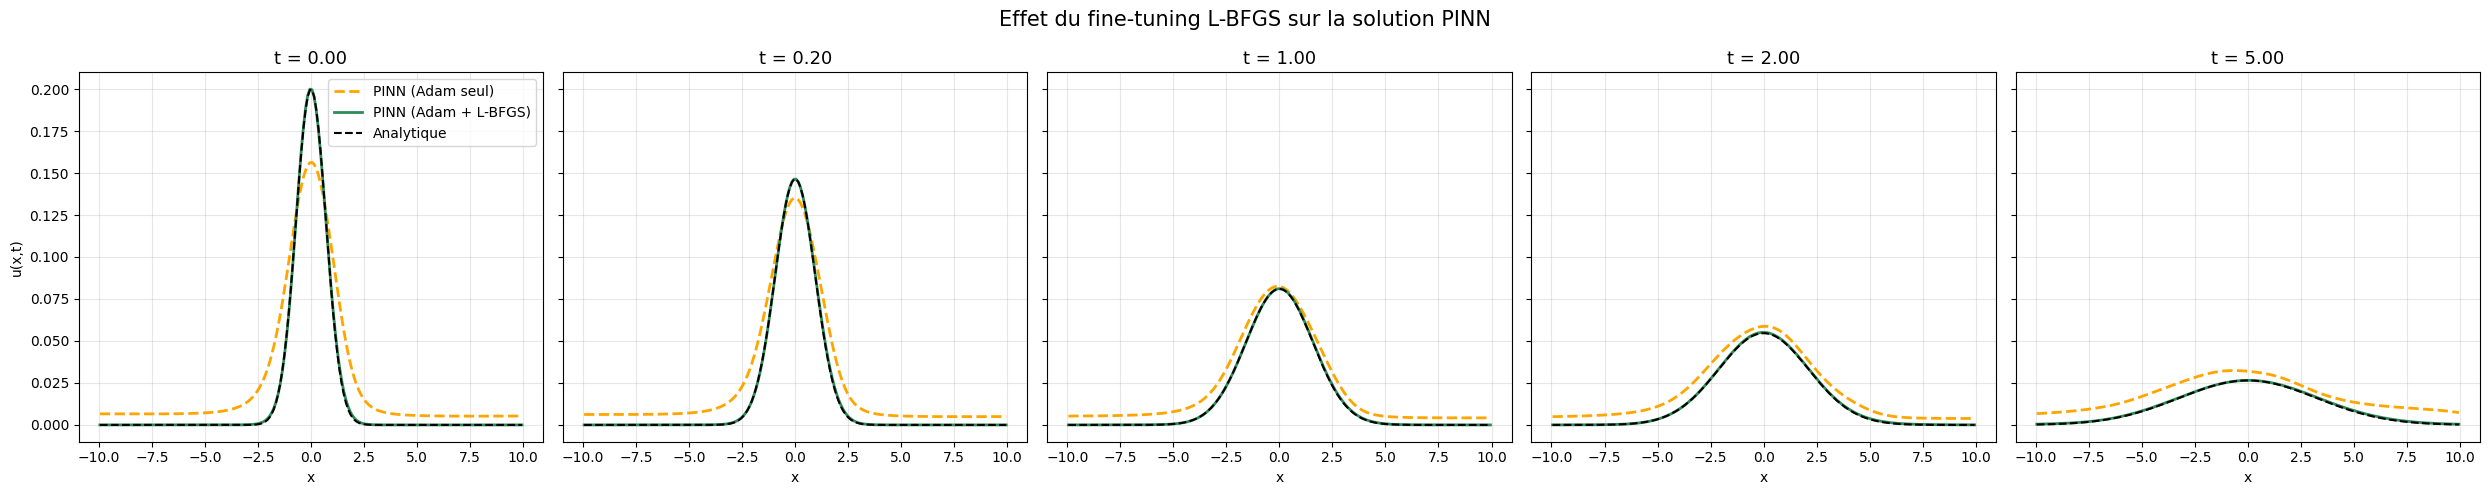

In [102]:
# On compare la solution PINN juste après Adam (avant_) à celle après
# L-BFGS (apres_) : le fine-tuning doit rapprocher la courbe verte
# (Adam+L-BFGS) de la courbe noire (analytique) par rapport à l'orange.
temps_a_tracer = [1e-4, 0.2, 1, 2, T]
fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5), sharey=True)

for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    
    ax.plot(x_grille, U_pinn_grille_avant[idx, :], color='orange', linestyle='--', linewidth=2, label="PINN (Adam seul)")
    
    ax.plot(x_grille, U_pinn_grille_apres[idx, :], color='seagreen', linewidth=2, label="PINN (Adam + L-BFGS)")
    ax.plot(x_grille, U_exacte_ti, color='black', linewidth=1.5, linestyle='--', label="Analytique")
    

    ax.set_title(f"t = {ti:.2f}", fontsize=13)
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('u(x,t)')
axes[0].legend(fontsize=10)
plt.suptitle("Effet du fine-tuning L-BFGS sur la solution PINN", fontsize=15)
plt.tight_layout()
plt.savefig('effet_lbfgs.png', dpi=300, bbox_inches='tight')
plt.show()

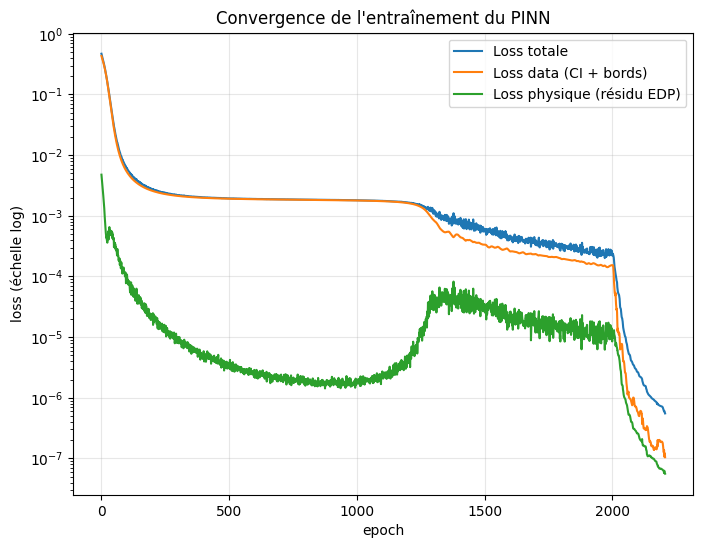

In [103]:
# --- Courbes de convergence : loss totale / data / physique -------------
# En échelle log : si loss_phys diminue nettement, le PINN a appris à
# satisfaire l'EDP ; si loss_data reste haute, il n'a pas bien ajusté
# la condition initiale / les bords.
plt.figure(figsize=(8, 6))
plt.semilogy(hist['total_loss'], label='Loss totale')
plt.semilogy(hist['data_loss'], label='Loss data (CI + bords)')
plt.semilogy(hist['phys_loss'], label='Loss physique (résidu EDP)')
plt.xlabel('epoch')
plt.ylabel('loss (échelle log)')
plt.title("Convergence de l'entraînement du PINN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('loss_PINN.png', dpi=300, bbox_inches='tight')
plt.show()

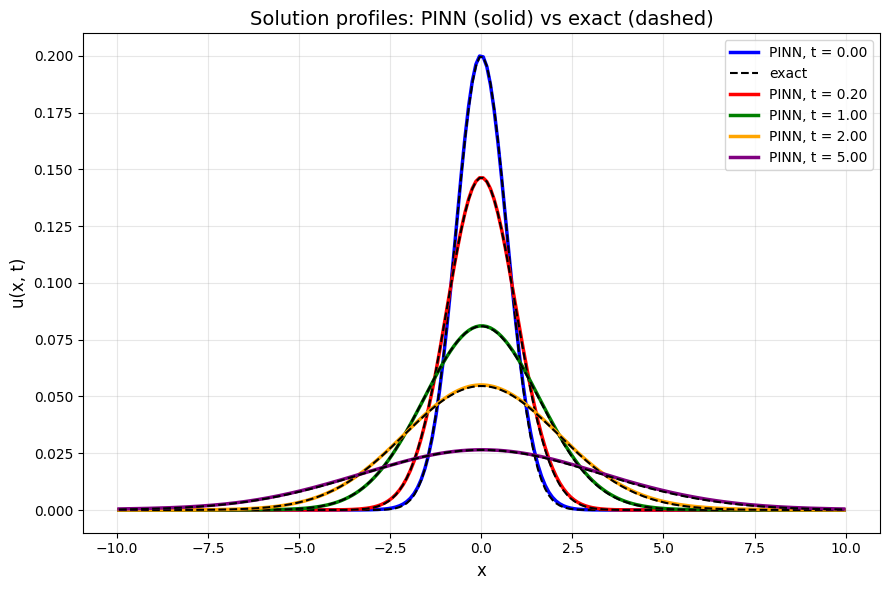

In [104]:
pinn.eval()
with torch.no_grad():
    xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]), dtype=torch.float32)
    U_pinn_grille = pinn(xt_grille).numpy().reshape(X_mesh.shape)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]
colors = ["blue", "red", "green", "orange", "purple"]

fig, ax = plt.subplots(figsize=(9, 6))

for i, (c, ti) in enumerate(zip(colors, temps_a_tracer)):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    # Courbe PINN (pleine, colorée)
    ax.plot(x_grille, U_pinn_grille[idx, :], color=c, linewidth=2.5,
            label=f"PINN, t = {ti:.2f}")

    # Courbe exacte (pointillée noire) — une seule entrée dans la légende
    ax.plot(x_grille, U_exacte_ti, color='black', linestyle='--', linewidth=1.5,
            label="exact" if i == 0 else None)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('u(x, t)', fontsize=12)
ax.set_title("Solution profiles: PINN (solid) vs exact (dashed)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('comparaison_PINN.png', dpi=300, bbox_inches='tight')
plt.show()

### Comparaison finale à 4 courbes : Analytique / VF / MLP / PINN 

 U_vf_grille et U_mlp_grille viennent de la cellule 7 (chargement du VF
et du MLP) : elles ne sont PAS recalculées ici, donc si tu changes A, D,
alpha, sigma entre-temps, ces deux courbes seront désynchronisées de
U_pinn_grille.

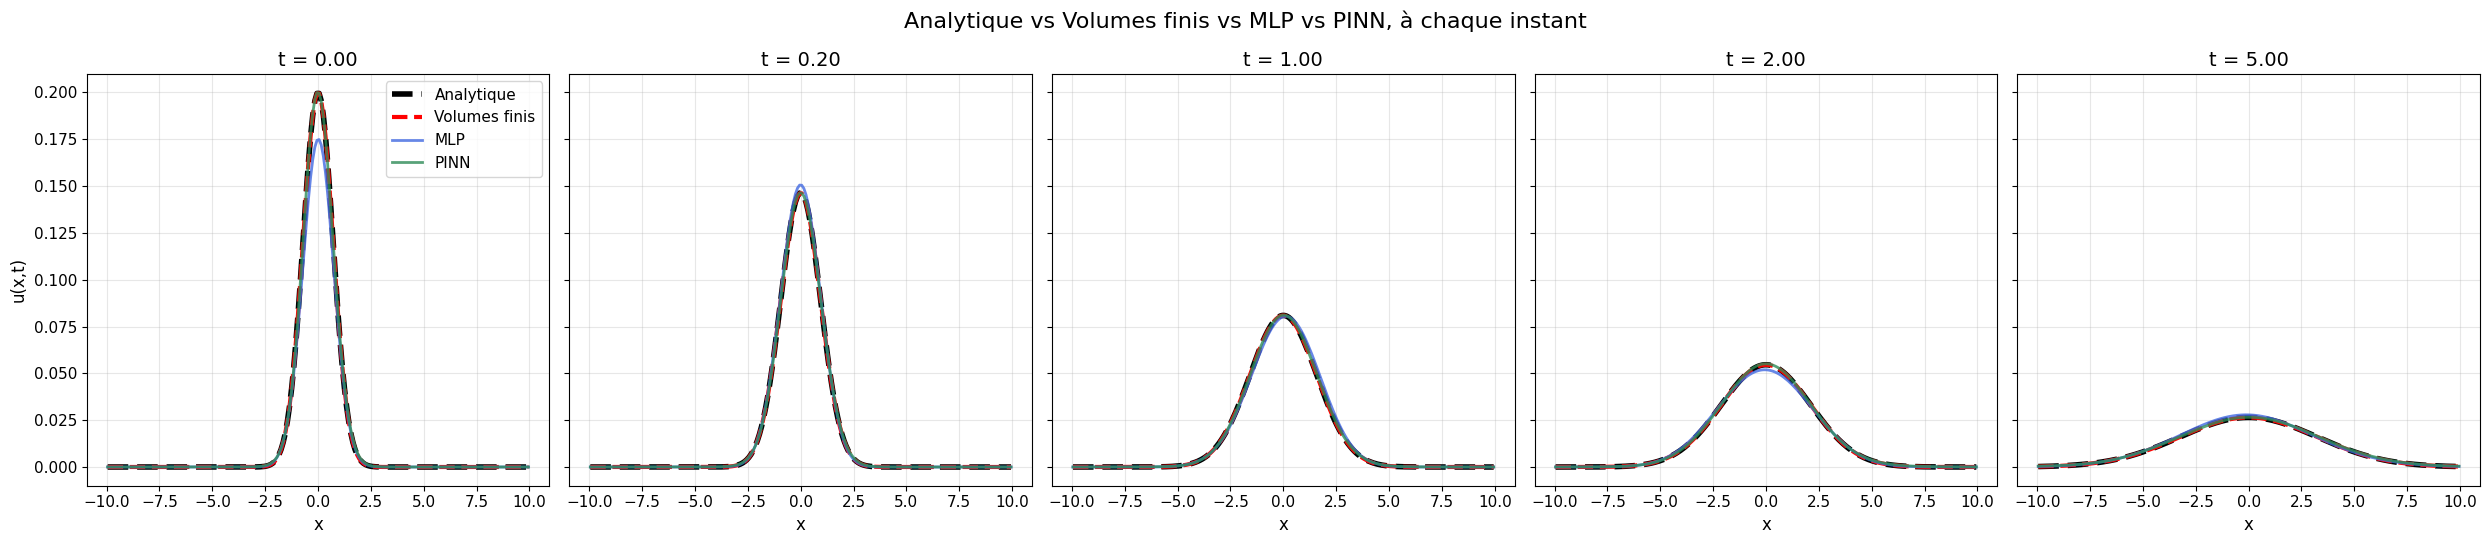

In [105]:
pinn.eval()
with torch.no_grad():
    xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]),
                              dtype=torch.float32)
    U_pinn_grille = pinn(xt_grille).numpy().reshape(X_mesh.shape)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]

fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5.5), sharey=True)

for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    ax.plot(x_grille, U_exacte_ti, color='black', linewidth=4,linestyle='--', label="Analytique")
    ax.plot(x_grille, U_vf_grille[idx, :], color='red', linestyle='--', linewidth=3, label="Volumes finis")
    ax.plot(x_grille, U_mlp_grille[idx, :], color='royalblue', linewidth=2, alpha=0.8, label="MLP")
    ax.plot(x_grille, U_pinn_grille[idx, :], color='seagreen', linewidth=2, alpha=0.8, label="PINN")

    ax.set_title(f"t = {ti:.2f}", fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('u(x,t)', fontsize=12)
axes[0].legend(fontsize=11)
plt.suptitle("Analytique vs Volumes finis vs MLP vs PINN, à chaque instant", fontsize=16)
plt.tight_layout()
plt.savefig('comparaison_4_methodes.png', dpi=300, bbox_inches='tight')
plt.show()

 --- Vérification sur les points d'entraînement eux-mêmes (CI + bords) ---
 
 Sert de sanity check : si l'erreur élevée ici indiquerait que le PINN

 n'a même pas réussi à ajuster les données qu'il a vues directement.

In [106]:
pinn.eval()
with torch.no_grad():
    u_pred_train = pinn(X_data)
    err_train = (u_pred_train - u_data).numpy()

MSE_train = np.mean(err_train**2)
print(f"Erreur sur points d'entraînement (CI+bords) | MSE = {MSE_train:.3e}")

Erreur sur points d'entraînement (CI+bords) | MSE = 1.046e-07


### Erreur du PINN sur toute la grille (jamais vue pendant l'entraînement)

In [107]:
U_exacte_grille = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
diff_grille = U_pinn_grille - U_exacte_grille

MSE_grille = np.mean(diff_grille**2)
L2_grille = np.sqrt(MSE_grille)
Linf_grille = np.max(np.abs(diff_grille))

print(f"Erreur sur grille complète (jamais vue)    | MSE = {MSE_grille:.3e}")
print(f"                                            | L2  = {L2_grille:.3e}")
print(f"                                            | L∞  = {Linf_grille:.3e}")

Erreur sur grille complète (jamais vue)    | MSE = 5.605e-08
                                            | L2  = 2.367e-04
                                            | L∞  = 1.870e-03


### Comparaison finale des erreurs L2 (vs analytique) des 3 méthodes ---
C'est LA figure de conclusion du stage : si le PINN a bien convergé,
sa courbe (verte) doit être globalement en dessous ou comparable à
celle du MLP, en particulier sur les scénarios hors régime d'entraînement.

dx_grille = 0.100000
Erreur L2 max — Volumes finis : 0.000182
Erreur L2 max — MLP           : 0.025164
Erreur L2 max — PINN          : 0.002018


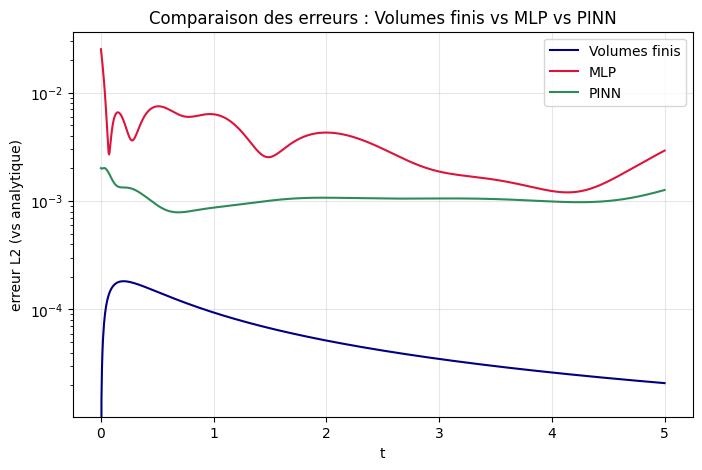

In [108]:
# Pas spatial de la grille d'évaluation
dx_grille = x_grille[1] - x_grille[0]

print(f"dx_grille = {dx_grille:.6f}")
# --- Prédiction du PINN sur la même grille (t_grille, x_grille) ---
pinn.eval()
U_pinn_grille = np.zeros_like(U_exacte_grille)  # shape (n_t, n_x)

with torch.no_grad():
    for i, ti in enumerate(t_grille):
        xt = torch.tensor(
            np.column_stack([x_grille, np.full_like(x_grille, ti)]),
            dtype=torch.float32
        )
        U_pinn_grille[i, :] = pinn(xt).numpy().flatten()

# --- Erreurs globales des trois méthodes par rapport à l'analytique, sur la grille ---
erreur_vf = U_vf_grille - U_exacte_grille
erreur_mlp = U_mlp_grille - U_exacte_grille
erreur_pinn = U_pinn_grille - U_exacte_grille

L2_vf = np.sqrt(dx_grille * np.sum(erreur_vf**2, axis=1))
L2_mlp = np.sqrt(dx_grille * np.sum(erreur_mlp**2, axis=1))
L2_pinn = np.sqrt(dx_grille * np.sum(erreur_pinn**2, axis=1))

print(f"Erreur L2 max — Volumes finis : {L2_vf.max():.6f}")
print(f"Erreur L2 max — MLP           : {L2_mlp.max():.6f}")
print(f"Erreur L2 max — PINN          : {L2_pinn.max():.6f}")

plt.figure(figsize=(8, 5))
plt.plot(t_grille, L2_vf, label="Volumes finis", color='navy')
plt.plot(t_grille, L2_mlp, label="MLP", color='crimson')
plt.plot(t_grille, L2_pinn, label="PINN", color='seagreen')
plt.xlabel('t')
plt.ylabel('erreur L2 (vs analytique)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Comparaison des erreurs : Volumes finis vs MLP vs PINN")
plt.savefig('comparaison_erreurs_L2_3methodes.png', dpi=300, bbox_inches='tight')
plt.show()